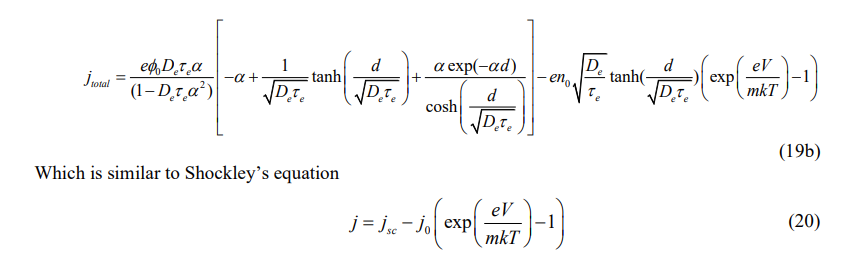


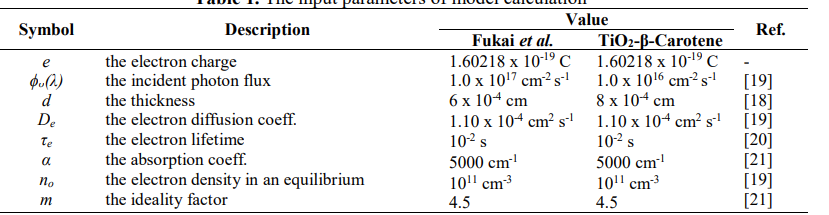



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
from sklearn.metrics import r2_score
from scipy.constants import physical_constants
import warnings
warnings.filterwarnings("ignore")
#if error
import scienceplots
plt.style.use(['science','notebook','grid'])


data = pd.read_excel('./data/Data Efisiensi DSSC Erma.xlsx',sheet_name=None)
sheets = tuple(data.keys())

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [3]:
def set_float128():
    global float, linspace, array
    float = np.float128  # Override Python's float
    linspace = lambda start, stop, num: np.linspace(start, stop, num, dtype=np.float128)
    array = lambda data: np.array(data, dtype=np.float128)

# Call at the beginning of the script
set_float128()

In [8]:

def find_m(sheet,m=2.5):
  if sheet not in data.keys():
    print(f"Sheet '{sheet}' not found in the Excel file.")
    return

  x_data =data[sheet].iloc[:,2]
  y_data =data[sheet].iloc[:,1]/0.2
  e  = 1.60217663e-19
  k = 1.38064e-23     # Konstanta Boltzmann dalam J/K
  T = 300          # Suhu dalam Kelvin

  if sheet == sheets[2]:
    e =-e

  f20= lambda x,jsc,j0,m : jsc-j0*((np.exp((e * x) / (m * k * T)) - 1))
  ppram,pcov = curve_fit(f20,x_data,y_data,p0=[1,1,m])
  return ppram[2]



def plot(sheet,N=3,M=None,phi=None,get_atribute=False,scale:float=1e1,delta=False,T=300):
  if sheet not in data.keys():
    print(f"Sheet '{sheet}' not found in the Excel file.")
  T = T     # Suhu dalam Kelvin
  x_data =data[sheet].iloc[:,2]
  y_data =data[sheet].iloc[:,1]/0.2
  # Constants that don’t change during fitting
  e = physical_constants['elementary charge'][0]*scale
 *scale

  if sheet == sheets[2]:

    e = -e
  d = 0.0008         # Ketebalan dalam meter
  if phi is None:
    phi = 2.52e17
  m = find_m(sheet) if M is None else find_m(sheet, M)

  # Define the equation as a Python function
  def calculate_y(x, De, Te, alpha, n0):
      term1 = (e * phi * De * Te * alpha) / (1 - (De * Te * (alpha**2)))
      term2 = (-alpha) + ((1 / np.sqrt(De * Te)) * np.tanh(d / np.sqrt(De * Te)))
      term3 = (alpha * np.exp(-alpha * d)) / np.cosh(d / np.sqrt(De * Te))
      first_part = term1 * (term2 + term3)
      second_part = e * n0 * np.sqrt(De / Te) * np.tanh(d / np.sqrt(De * Te))
      third_part = (np.exp((e * x) / (m * k * T)) - 1)

      y = first_part - second_part*third_part
      return y

  def jsc_j0(x, De, Te, alpha, n0):
    term1 = (e * phi * De * Te * alpha) / (1 - (De * Te * (alpha**2)))
    term2 = (-alpha) + ((1 / np.sqrt(De * Te)) * np.tanh(d / np.sqrt(De * Te)))
    term3 = (alpha * np.exp(-alpha * d)) / np.cosh(d / np.sqrt(De * Te))

    first_part = term1 * (term2 + term3)
    second_part = e * n0 * np.sqrt(De / Te) * np.tanh(d / np.sqrt(De * Te))
    return   first_part, second_part


  # Initial guesses for the parameters (adjust these based on your knowledge of the system)
  initial_guesses = [1e-4, 1e-2, 5000, 1e15]
  # Perform curve fitting
  params, covariance = curve_fit(calculate_y, x_data, y_data, p0=initial_guesses)
  jscj0 = jsc_j0(x_data, *params)

  ketidakpastian = np.sqrt(np.diag(covariance))

  # Calculate fitted values of y using the fitted parameters
  y_fitted = calculate_y(x_data, *params)
  r2 = r2_score(y_data, y_fitted)

  # Plot the data and the fitted curve
  plt.scatter(x_data, y_data, s=40, facecolors='none', edgecolors='black', label=sheet)
  plt.plot(x_data, y_fitted, label="Fitted Curve", color="red")
  param_dict = {
    "$D_e$": f"{params[0]:.{N}e} ",
    "$\\tau_e$": f"{params[1]:.{N}e} ",
    "$\\alpha$": f"{params[2]:.{N}e} ",
    "$n_0$": f"{params[3]:.{N}e}",
    "$m$": f"{m:.{N+1}e}",
    "$R^2$": f"{r2:.{N}e}",
    "$j_{sc}$": f"{jscj0[0]*scale:.{N}e}",
    "$j_0$": f"{jscj0[1]*scale:.{N}e}",
    "$\\Delta y$": f"{np.average(y_fitted-y_data):.{N}e}",
    "Scale": f"{1/scale}"
    }
  table_data = [[key, value] for key, value in param_dict.items()]
  table = plt.table(cellText=table_data,
                  colLabels=["Parameter", "Value"],
                  cellLoc="center",
                  loc="upper right",
                  colWidths=[0.3,0.5+N/(10+N**2/2)],
                  bbox=[1.01, 0.45, 0.5, 0.4])  # Adjust bbox to position the table
  table.auto_set_font_size(True)
  table.set_fontsize(10)
  plt.title(sheet)
  plt.xlabel(f"Voltage (V)")
  plt.ylabel(f"Current Density ({data[sheet].columns[1]}$/cm^2$)")
  plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0.,prop ={'size':11})
  plt.show()

  if delta is True:
    return np.average(y_fitted-y_data)

  if get_atribute is True:
    atribute = [[sheet],[y_fitted],[params],[covariance],[ketidakpastian],[r2],[np.average(y_fitted-y_data)]]
    return atribute
  else:
    return

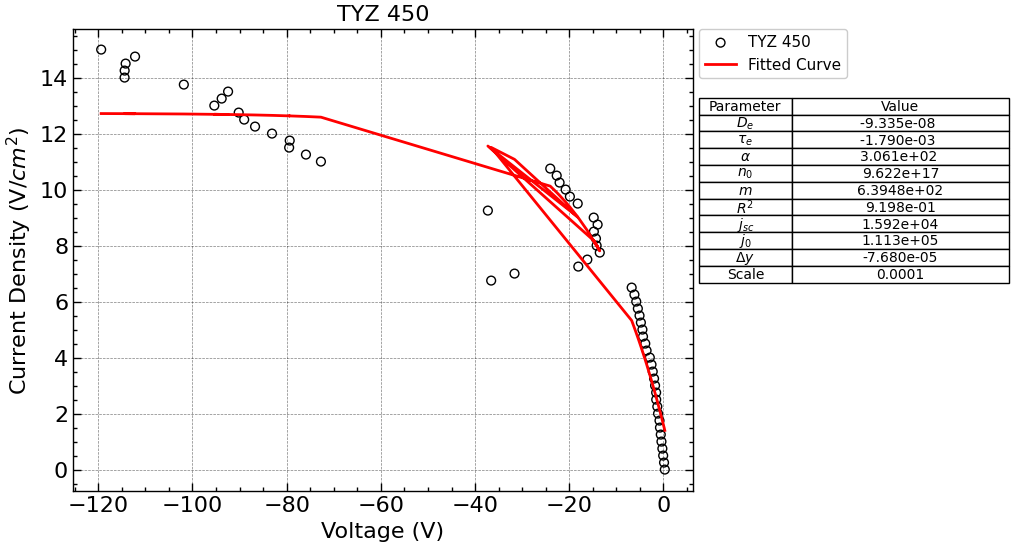

TypeError: unsupported operand type(s) for /: 'datetime.time' and 'float'

In [5]:
#s = 4,3, ,5
plot(sheet=sheets[0],scale=1e4)
plot(sheet=sheets[1],scale=1e3)
plot(sheet=sheets[2],scale=1e0)
plot(sheet=sheets[3],scale=1e5)


'1e9'

In [6]:
from scipy.constants import physical_constants
def nearest_to_zero(X):
  if not X.size:
      return None
  return np.argmin(np.abs(X)),X[np.argmin(np.abs(X))]

M=10195611.127649462
f = lambda x,m:(np.exp((physical_constants['elementary charge'][0] * x) / (m * physical_constants['Boltzmann constant'][0] * 300)) - 1)
X,Y = XY(sheets[2])

jsc = Y[nearest_to_zero(X)[0]]
j0 = (Y[nearest_to_zero(Y)[0]]-jsc)/f(X[nearest_to_zero(Y)[0]],M)

jsc1 = 2*j0-jsc
j01 = -j0

M=10195611.127649462
f = lambda x,m:(np.exp((-physical_constants['elementary charge'][0] * x) / (m * physical_constants['Boltzmann constant'][0] * 300)) - 1)
Y_fit =jsc1-j01*(f(X,M))
plt.plot(X,Y_fit)

jsc1,j01

NameError: name 'XY' is not defined

In [7]:
e = physical_constants['elementary charge'][0]
f20= lambda x,jsc,j0,m : jsc1-j01*((np.exp((e * x) / (m * physical_constants['Boltzmann constant'][0] * 300)) - 1))
ppram,pcov = curve_fit(f20,X,Y,p0=[1,1,1])
print(f'm = {ppram[2]}')

NameError: name 'X' is not defined

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# Load the Excel file
data = pd.read_excel("/content/pom_brownish.xlsx")

# Assume the first column is x (tegangan) and the second column is y (j_total)
x_data = data.iloc[:, 0]  # Kolom pertama sebagai x
y_data = data.iloc[:, 2]  # Kolom kedua sebagai y

# Constants that don’t change during fitting
e = 1.60218e-19  # Muatan elektron dalam Coulomb
k = 1.38e-23     # Konstanta Boltzmann dalam J/K
T = 300          # Suhu dalam Kelvin

# Define the equation as a Python function
def calculate_y(x, jsc, j0, m):
    y = jsc - (j0*(np.exp((e*x)/(m*k*T)) - 1))
    return y

# Initial guesses for the parameters (adjust these based on your knowledge of the system)
initial_guesses = [1,1,2.5]

# Perform curve fitting
params, covariance = curve_fit(calculate_y, x_data, y_data, p0=initial_guesses)

# Print the fitted parameters
print("Fitted parameters:")
print("jsc =", params[0])
print("j0 =", params[1])
print("m =", params[2])

# Calculate fitted values of y using the fitted parameters
y_fitted = calculate_y(x_data, *params)

# Plot the data and the fitted curve
plt.scatter(x_data, y_data, label="Data", color="blue")
plt.plot(x_data, y_fitted, label="Fitted Curve", color="red")
plt.xlabel("x (Voltage)")
plt.ylabel("y (j_total)")
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/pom_brownish.xlsx'

In [ ]:
# このファイルには日本語のテキストを含めることはできません。
# このファイルはPythonのコードのみを含んでいます。
# 上記のコードをそのまま使用してください。